In [8]:
# imports
from facedancer import *
from pprint import pprint

In [10]:
strings = {
    1: "Agilent Technologies",
    2: "USB ECal Module"
}

In [11]:
device = USBDevice.from_binary_descriptor(device_data, strings)
pprint(device)

USBDevice(name='generic device',
          device_class=0,
          device_subclass=0,
          protocol_revision_number=0,
          max_packet_size_ep0=64,
          vendor_id=2391,
          product_id=1,
          manufacturer_string=<facedancer.descriptor.StringRef object at 0x7c663c2b09e0>,
          product_string=<facedancer.descriptor.StringRef object at 0x7c663c2b06b0>,
          serial_number_string=<facedancer.descriptor.StringRef object at 0x7c663c22b250>,
          supported_languages=(<LanguageIDs.ENGLISH_US: 1033>,),
          device_revision=3,
          usb_spec_version=272,
          device_speed=None,
          requestable_descriptors={<DescriptorTypes.DEVICE: 1>: <function USBBaseDevice.__post_init__.<locals>.<lambda> at 0x7c663c37ec00>,
                                   <DescriptorTypes.CONFIGURATION: 2>: <bound method USBBaseDevice.get_configuration_descriptor of USBDevice(name='generic device', device_class=0, device_subclass=0, protocol_revision_number=0, ma

In [12]:
config = USBConfiguration.from_binary_descriptor(device_config)
pprint(config)

device.add_configuration(config)

USBConfiguration(number=1,
                 configuration_string=<facedancer.descriptor.StringRef object at 0x7c663c2725d0>,
                 max_power=500,
                 self_powered=False,
                 supports_remote_wakeup=False,
                 parent=None,
                 interfaces={(0, 0): USBInterface(name=None,
                                                  number=0,
                                                  alternate=0,
                                                  class_number=0,
                                                  subclass_number=0,
                                                  protocol_number=0,
                                                  interface_string=<facedancer.descriptor.StringRef object at 0x7c663c2724e0>,
                                                  attached_descriptors=[],
                                                  requestable_descriptors={},
                                                  endpoints={

In [13]:
print(device.generate_code())
print(device.generate_code(), file=open('emulate.py', 'w'))


@use_inner_classes_automatically
class Device(USBDevice):
    device_speed             = None
    device_class             = 0
    device_subclass          = 0
    protocol_revision_number = 0
    max_packet_size_ep0      = 64
    vendor_id                = 0x0957
    product_id               = 0x0001
    manufacturer_string      = (1, 'Agilent Technologies')
    product_string           = (2, 'USB ECal Module')
    serial_number_string     = None
    supported_languages      = (LanguageIDs.ENGLISH_US,)
    device_revision          = 0x0003
    usb_spec_version         = 0x0110

    class Configuration_1(USBConfiguration):
        number                 = 1
        configuration_string   = None
        max_power              = 500
        self_powered           = False
        supports_remote_wakeup = False

        class Interface_0(USBInterface):
            number           = 0
            alternate        = 0
            class_number     = 0
            subclass_number  = 0
      

In [ ]:
from eeprom import EEPROM


eeprom = EEPROM.from_file("data/EEPROM/n4691-60006.bin")

'53'

In [7]:
from eeprom import EEPROM
from pprint import pprint
from datetime import date

eeprom = EEPROM.from_file("data/EEPROM/n4691d.bin")

eeprom.mfg_location = "Belgium Flanders"
eeprom.mfg_date = date(2026, 7, 14)
eeprom.serial = "Achim"
eeprom.lot_code = "one too many"
eeprom.model = "N4691E"

eeprom.default_config = None
eeprom.confidence_config = None
eeprom.freq_break = None

for i in range(len(eeprom.configs)):
    for j in range(len(eeprom.configs[i])):
        eeprom.configs[i][j] = eeprom.configs[i][j]['0.1-18ghz']

eeprom.to_file("data/EEPROM/n4691d-modified.bin")

with open("data/EEPROM/n4691d-modified.hex", "w") as f:
    print(eeprom, file=f)

In [8]:
eeprom[0:0x64]

b'HP85060C ECAL\x00\xff\xff\xff\xff\xff\xffd\x00Nov 28 1994\x00d\x00\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\x02\x00\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff'

In [15]:
data = bytearray(b"\xff" * 0x1000)        
data[0:0x64] = (
            b"HP85060C ECAL\x00\xff\xff\xff\xff\xff\xffd\x00Nov 28 1994\x00d\x00\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\x02\x00\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff"
        )
print(data)

bytearray(b'HP85060C ECAL\x00\xff\xff\xff\xff\xff\xffd\x00Nov 28 1994\x00d\x00\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\x02\x00\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\x

In [19]:
struct.pack_into("<12s", data, 0x64, "test".encode('utf-8'))
print(data[0x60:0x80])

bytearray(b'\xff\xff\xff\xfftest\x00\x00\x00\x00\x00\x00\x00\x00\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff')


4 583 4 0x1490 0x1498 0x5d78
['9 (0x9)', '15 (0xf)', '11 (0xb)', '43 (0x2b)']
Read (0, 0, 0) from 0x1498 to 0x26d0
Read (1, 0, 0) from 0x26d0 to 0x3908
Read (2, 0, 0) from 0x3908 to 0x4b40
Read (3, 0, 0) from 0x4b40 to 0x5d78


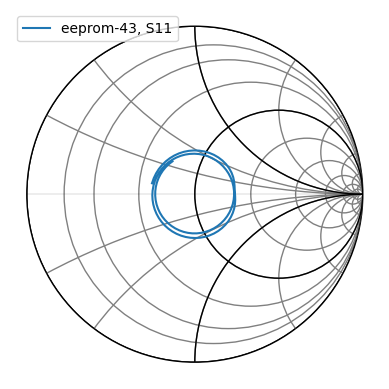

In [6]:
import struct
import numpy as np
import matplotlib.pyplot as plt
import skrf as rf
import subprocess

# id = "n4691-60006"
id = "n4691d"

with open(f'data/EEPROM/{id}.bin', 'rb') as fp:
    eeprom = fp.read()

i = 0x190
nfreqs = struct.unpack_from("<H", eeprom, i)[0]; i += 2
freq_address = struct.unpack_from("<I", eeprom, i)[0]; i += 4

freqs = np.frombuffer(eeprom, dtype=np.float64, count=nfreqs, offset=freq_address)

i += 14 * 0
nconfig_shorts = struct.unpack_from("<H", eeprom, i)[0]; i += 2
npoints = struct.unpack_from("<H", eeprom, i)[0]; i += 2
nentries = struct.unpack_from("<H", eeprom, i)[0]; i += 2
config_header_address = struct.unpack_from("<I", eeprom, i)[0]; i += 4
config_data_address = struct.unpack_from("<I", eeprom, i)[0]; i += 4

next_config_header_address = struct.unpack_from("<I", eeprom, i + 6)[0]

print(nconfig_shorts, npoints, nentries, hex(config_header_address), hex(config_data_address), hex(next_config_header_address))

config_shorts = [] * nconfig_shorts
i = 0
for _ in range(nconfig_shorts):
    config_shorts.append(struct.unpack_from("<H", eeprom, config_header_address + i)[0])
    i += 2

print([f"{s} ({hex(s)})" for s in config_shorts])

dimen = int(np.sqrt(nentries // nconfig_shorts))
config_1 = np.zeros((nconfig_shorts, npoints, dimen, dimen), dtype=np.complex64)

for i in range(nconfig_shorts):
    for l in range(dimen):
        for m in range(dimen):
            config_1[i, :, l, m] = np.frombuffer(eeprom, dtype=np.complex64, count=npoints, offset=config_data_address + (i * dimen * dimen + l * dimen + m) * npoints * 8)
            print(f"Read {i, l, m} from {hex(config_data_address + (i * dimen * dimen + l * dimen + m) * npoints * 8)} to {hex(config_data_address + (i * dimen * dimen + l * dimen + m + 1) * npoints * 8)}")

idx = 3

ntwk_eeprom = rf.Network(frequency=freqs, s=config_1[idx, :], name=f'eeprom-{config_shorts[idx]}', f_unit='Hz', z0=50)['0.1-6ghz']
# ntwk_meas = rf.Network(f'data/n4691-60006/eeprom-{config_shorts[idx]}.s2p')

ntwk_eeprom['0.1-6ghz'].s11.plot_s_smith()
# # ntwk_eeprom['0.1-6ghz'].s12.plot_s_db()
# # ntwk_meas['0.1-6ghz'].s11.plot_s_smith()

<Figure size 640x480 with 0 Axes>

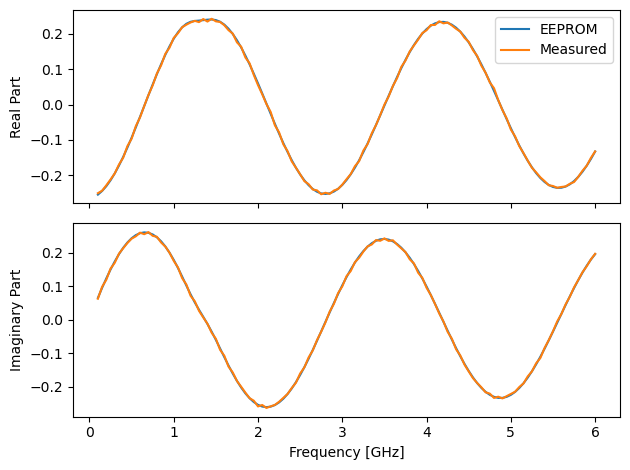

In [79]:
ntwk_measured = rf.Network(f"data/{id}/eeprom-{config_shorts[idx]}.s1p", name='measured')

plt.figure()
fig, axs = plt.subplots(2, 1, sharex=True)

axs[0].plot(ntwk_eeprom.f * 1e-9, np.real(ntwk_eeprom.s[:, 0, 0]), label='EEPROM')
axs[0].plot(ntwk_measured.f * 1e-9, np.real(ntwk_measured.s[:, 0, 0]), label='Measured')
axs[0].set_ylabel('Real Part')
axs[0].legend()

axs[1].plot(ntwk_eeprom.f * 1e-9, np.imag(ntwk_eeprom.s[:, 0, 0]), label='EEPROM')
axs[1].plot(ntwk_measured.f * 1e-9, np.imag(ntwk_measured.s[:, 0, 0]), label='Measured')
axs[1].set_xlabel('Frequency [GHz]')
axs[1].set_ylabel('Imaginary Part')

fig.set_tight_layout(True)
plt.show()